# Startup Profit Prediction
**Business question:** Which spending drives startup profit, and can we predict profit from it?

In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
df = pd.read_csv("../data/50_Startups.csv")
df.head()

In [3]:
print(df.shape)
df.info()

(50, 5)
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.5 KB


In [ ]:
df.describe()

In [5]:
df[(df["R&D Spend"] == 0) | (df["Marketing Spend"] == 0)]

,R&D Spend,Administration,Marketing Spend,State,Profit
19,86419.70,153514.11,0.00,New York,122776.86
47,0.00,135426.92,0.00,California,42559.73
48,542.05,51743.15,0.00,New York,35673.41
49,0.00,116983.80,45173.06,California,14681.40


In [6]:
df.sort_values("Profit").head(3)

,R&D Spend,Administration,Marketing Spend,State,Profit
49,0.00,116983.80,45173.06,California,14681.40
48,542.05,51743.15,0.00,New York,35673.41
47,0.00,135426.92,0.00,California,42559.73


In [7]:
df["State"].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

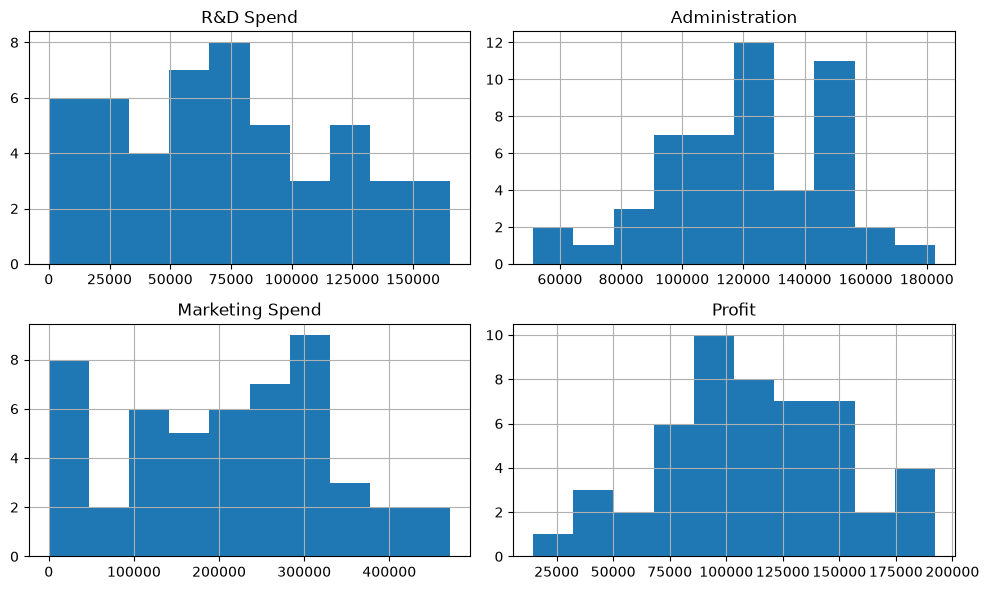

In [8]:
import matplotlib.pyplot as plt

df.hist(figsize=(10, 6), bins=10)
plt.tight_layout()
plt.show()

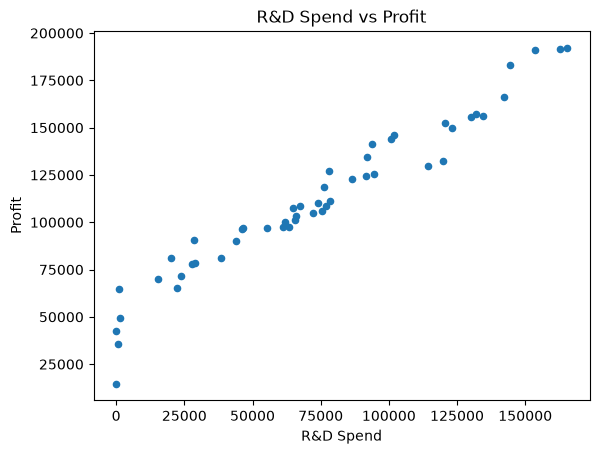

In [9]:
df.plot.scatter(x="R&D Spend", y="Profit", title="R&D Spend vs Profit")
plt.show()

In [10]:
df.corr(numeric_only=True)["Profit"].sort_values(ascending=False)

Profit             1.000000
R&D Spend          0.972900
Marketing Spend    0.747766
Administration     0.200717
Name: Profit, dtype: float64

In [1]:
import pandas as pd

df = pd.read_csv("../data/50_Startups.csv")

X = df[["R&D Spend", "Administration", "Marketing Spend"]]
y = df["Profit"]

print(X.shape, y.shape)

(50, 3) (50,)


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(40, 3) (10, 3)


In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

comparison = pd.DataFrame({"Actual": y_test, "Predicted": y_pred.round(0)})
comparison

,Actual,Predicted
13,134307.35,126703.0
39,81005.76,84895.0
30,99937.59,98893.0
45,64926.08,46502.0
17,125370.37,129128.0
48,35673.41,50993.0
26,105733.54,109017.0
25,107404.34,100878.0
32,97427.84,97701.0
19,122776.86,113106.0


In [4]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse:,.0f}")

RMSE: 8,996


In [5]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(f"R²: {r2:.3f}")

R²: 0.900


In [7]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    LinearRegression(), X_train, y_train,
    cv=5, scoring="neg_root_mean_squared_error"
)
cv_rmse = -scores.mean()

print("RMSE per fold:", (-scores).round(0))
print(f"CV RMSE: {cv_rmse:,.0f}")

RMSE per fold: [ 7741.  9127.  8218.  7907. 14741.]
CV RMSE: 9,547


In [8]:
import sys
sys.path.append("..")

from src.data import load_data, split

X_train, X_test, y_train, y_test = split(load_data())
print(X_train.shape, X_test.shape)

(40, 3) (10, 3)


Step 1: Train XGBoost